In [1]:
from Main.Experiment_class import *
from Utils.theoretical_points import get_th_approx_data, snr_exp, snr_th
from scipy.ndimage import zoom

In [2]:
markersize = 15
capsize = 6
capthick = 2
linewidth = 7.5
elinewidth=2

In [7]:
obj = PIcode_experiment(None, False, False)
obj.load('Data/31st_August_Torino_run1.json')
times = np.linspace(0, 300, 31)
relaxation_time = 30
delays = obj.storage['bare_qubit']['delays']
N = 52000
N_bare = 2000
n = 12
obj._post_process(n)

In [8]:
fids_set_1_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids'][4])
fids_set_1_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids'][4])
fid_stds_set_1_ket0 = np.array(obj.storage[f'multi_qec_30_0']['fids_stds'][4])
fid_stds_set_1_ket1 = np.array(obj.storage[f'multi_qec_30_1']['fids_stds'][4])
p_set_1_ket0 = np.array(obj.storage['multi_qec_30_0']['success_rates'][4])
p_set_1_ket1 = np.array(obj.storage['multi_qec_30_1']['success_rates'][4])
bare_qubit_fids = np.array(obj.storage['bare_qubit']['fids'][58])
bare_stds = np.array(obj.storage['bare_qubit']['fids_stds'][58])
bare_snr_set_1 = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids, bare_stds) ]
snr_set_1_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_1_ket0, fid_stds_set_1_ket0)
])
snr_set_1_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_set_1_ket1, fid_stds_set_1_ket1)
])

In [27]:
def rm_middle_points(data, points: int =61):
    nd = [data[0]]
    for i in range (1, points):
        if i % 2 == 0:
            nd.append(data[i])
    return np.array(nd)


In [28]:
obj_sim1 = PIcode_experiment(None, False, False)
obj_sim1.load('Data/Set1_simulation.json')
delays_sim = obj_sim1.storage['bare_qubit']['delays']
obj_sim1._post_process(n)
fids_sim_set_1_ket0 = rm_middle_points(np.array(obj_sim1.storage[f'multi_qec_30_0']['fids'][0]))
fids_sim_set_1_ket1 = rm_middle_points(np.array(obj_sim1.storage[f'multi_qec_30_1']['fids'][0]))
fids_sim_stds_set_1_ket0 = rm_middle_points(np.array(obj_sim1.storage[f'multi_qec_30_0']['fids_stds'][0]))
fids_sim_stds_set_1_ket1 = rm_middle_points(np.array(obj_sim1.storage[f'multi_qec_30_1']['fids_stds'][0]))
p_sim_set_1_ket0 = rm_middle_points(np.array(obj_sim1.storage[f'multi_qec_30_0']['success_rates'][0]))
p_sim_set_1_ket1 = rm_middle_points(np.array(obj_sim1.storage[f'multi_qec_30_1']['success_rates'][0]))
snr_sim_set_1_ket0 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_1_ket0, fids_sim_stds_set_1_ket0)
])
snr_sim_set_1_ket1 = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_1_ket1, fids_sim_stds_set_1_ket1)
])
bare_qubit_fids_sim = rm_middle_points(np.array(obj_sim1.storage[f'bare_qubit']['fids'][1]))
bare_stds_sim = rm_middle_points(np.array(obj_sim1.storage['bare_qubit']['fids_stds'][1]))
bare_snr_set_1_sim = [ snr_exp(f, s, N_bare/n) for f, s in zip(bare_qubit_fids_sim, bare_stds_sim) ]

In [11]:
set1_T1 = 205
set1_T2 = 90
qubit_set1 = obj.storage['multi_qec_30_1']['qubit_pos'][4]
bare_f_measure = [obj.storage['bare_qubit']['fids'][qubit][0] for qubit in qubit_set1]
data_set1 = get_th_approx_data(set1_T1, set1_T2, times, relaxation_time)
bare_snr_set_1_th = snr_th(f=data_set1['bare_qubit']['fids'], p=1.0, f_measure=bare_f_measure[1], n_measure=1)
snr_set_1_ket0_th = snr_th(f=data_set1['multi_qec_0_approx']['fids'], p=data_set1['multi_qec_0_approx']['probs'], f_measure=np.mean(bare_f_measure), n_measure=4)
snr_set_1_ket1_th = snr_th(f=data_set1['multi_qec_1_approx']['fids'], p=data_set1['multi_qec_1_approx']['probs'], f_measure=np.mean(bare_f_measure), n_measure=4)

# Option 1

In [21]:
upper_line = np.abs(snr_set_1_ket0_th/bare_snr_set_1_th - snr_sim_set_1_ket0/bare_snr_set_1_sim)
lower_line = np.abs(snr_set_1_ket0/bare_snr_set_1 - snr_sim_set_1_ket0/bare_snr_set_1_sim)
middle_line = np.array(snr_sim_set_1_ket0/bare_snr_set_1_sim)
upper_line = zoom(upper_line, 20, order=5)
lower_line = zoom(lower_line, 20, order=5)
middle_line = zoom(middle_line, 20, order=5)
xn = np.linspace(0, 300, len(middle_line))

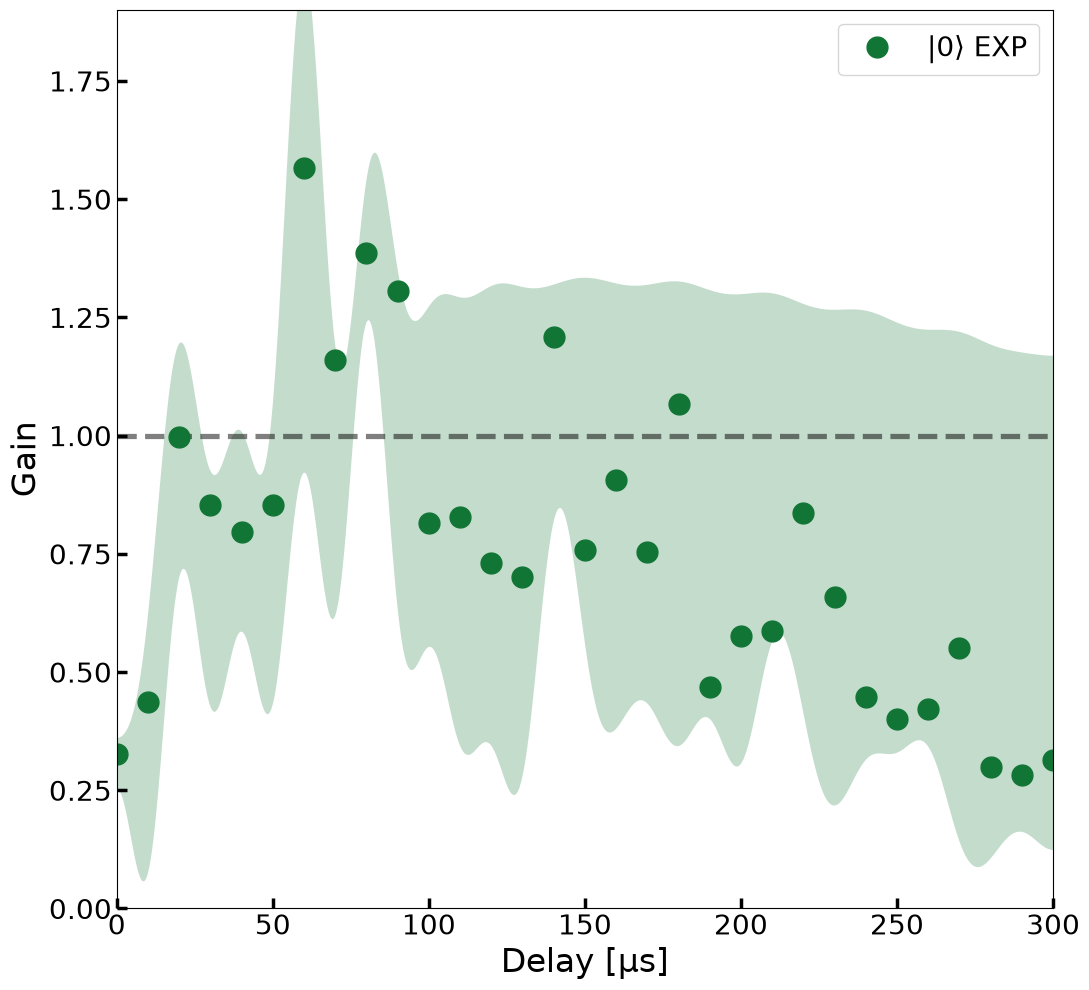

In [ ]:
plt.figure(figsize=(11, 10))
plt.axhline(y = 1.0, color = 'k', ls = '--', lw = linewidth/2, alpha = 0.5)

# Simulation
plt.errorbar(delays, snr_sim_set_1_ket0/bare_snr_set_1_sim, yerr = None, fmt='o', color = "#117535", ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ SIM', ls = None)

plt.fill_between(
    xn,
    middle_line + upper_line,
    middle_line - lower_line,
    color='#117535',
    linewidth=0,
    alpha=0.25
)


plt.xlim(0, 300)
plt.ylim(0, 1.9)
plt.legend(fontsize = 20)
plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
plt.xlabel('Delay [μs]', fontsize = 24)
plt.ylabel(r'Gain', fontsize = 24)
plt.tight_layout()
# plt.savefig('simulation_gain_Set_1_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)

# Option 2

In [23]:
upper_line = np.abs(snr_set_1_ket0_th/bare_snr_set_1_th)
lower_line = np.abs(snr_set_1_ket0/bare_snr_set_1)
# upper_line = zoom(upper_line, 20, order=5)
# lower_line = zoom(lower_line, 20, order=5)
xn = np.linspace(0, 300, len(upper_line))

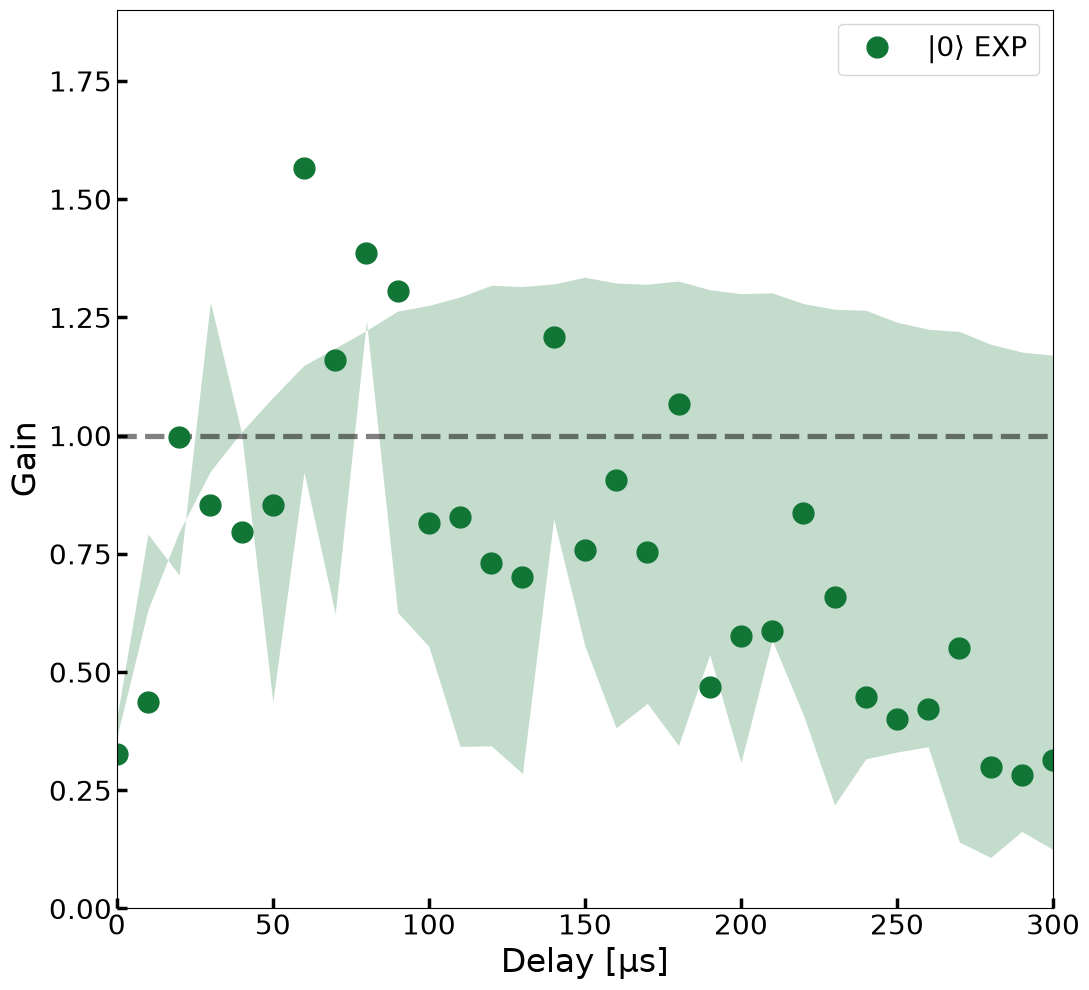

In [ ]:
plt.figure(figsize=(11, 10))
plt.axhline(y = 1.0, color = 'k', ls = '--', lw = linewidth/2, alpha = 0.5)

# Simulation
plt.errorbar(delays, snr_sim_set_1_ket0/bare_snr_set_1_sim, yerr = None, fmt='o', color = "#117535", ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ SIM', ls = None)

plt.fill_between(
    xn,
    upper_line,
    lower_line,
    color='#117535',
    linewidth=0,
    alpha=0.25
)


plt.xlim(0, 300)
plt.ylim(0, 1.9)
plt.legend(fontsize = 20)
plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
plt.xlabel('Delay [μs]', fontsize = 24)
plt.ylabel(r'Gain', fontsize = 24)
plt.tight_layout()
# plt.savefig('simulation_gain_Set_1_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)

# Option 3

In [30]:
fids_sim_set_1_ket0 + 2*fids_sim_stds_set_1_ket0
snr_upper = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_1_ket0 + 2*fids_sim_stds_set_1_ket0, fids_sim_stds_set_1_ket0)
])
snr_lower = np.array([
    snr_exp(f, sigma, N/n) for f, sigma in zip(fids_sim_set_1_ket0 - 2*fids_sim_stds_set_1_ket0, fids_sim_stds_set_1_ket0)
])

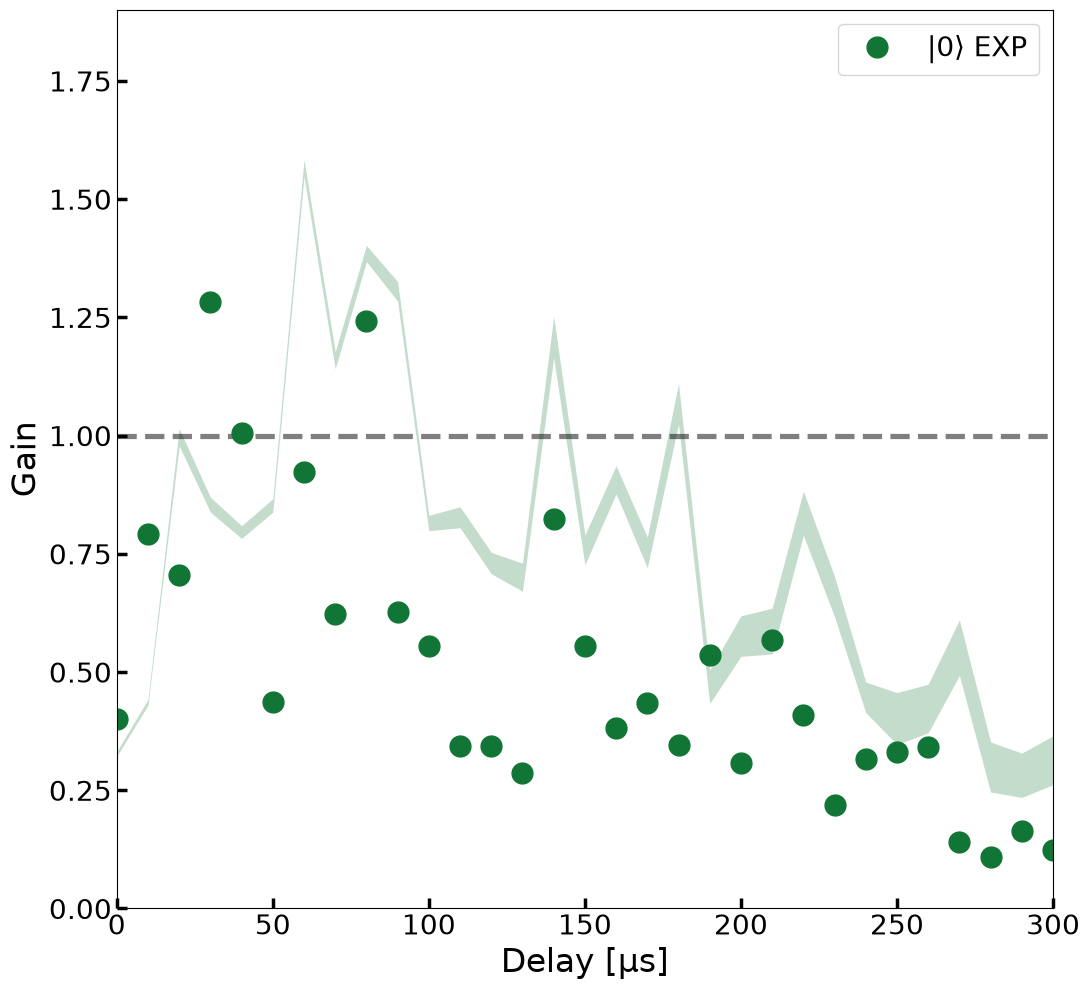

In [32]:
plt.figure(figsize=(11, 10))
plt.axhline(y = 1.0, color = 'k', ls = '--', lw = linewidth/2, alpha = 0.5)

# Simulation
plt.errorbar(delays, snr_set_1_ket0/bare_snr_set_1, yerr = None, fmt='o', color = "#117535", ecolor = '#117535', markersize = markersize, capsize = 5, capthick = 2, elinewidth = elinewidth, label = r'$|0\rangle$ EXP', ls = None)

plt.fill_between(
    xn,
    snr_upper/bare_snr_set_1_sim,
    snr_lower/bare_snr_set_1_sim,
    color='#117535',
    linewidth=0,
    alpha=0.25
)


plt.xlim(0, 300)
plt.ylim(0, 1.9)
plt.legend(fontsize = 20)
plt.tick_params(axis='both', direction='in', labelsize = 20, width = 2.5, size = 7.5)
# plt.tick_params(axis='both', direction='in', labelsize = 0, width = 2.5, size = 7.5, labelleft = False, labelbottom = False)
plt.xlabel('Delay [μs]', fontsize = 24)
plt.ylabel(r'Gain', fontsize = 24)
plt.tight_layout()
# plt.savefig('simulation_gain_Set_1_empty.pdf', bbox_inches='tight', pad_inches=0, dpi = 300)